# $r_i^2$ vs $J_i$ — por qué RV necesita una medida de salto (no $r^2$ directo)

La realized variance suma $r_i^2$: $\;RV_t=\sum_{i\in \text{día }t} r_i^2$.
Pero $r_i^2$ **no** distingue un *salto* de una ventana de *alta volatilidad continua*:
se dispara en ambos. Por eso el pipeline detecta saltos con la medida de **bipower
variation** (Barndorff–Nielsen–Shephard):

$$J_i = \max\!\left(r_i^2 - \tfrac{\pi}{2}\,|r_i|\,|r_{i-1}|,\; 0\right)$$

- $r_i^2$ = aporte a la varianza realizada (ruidoso, inflado por saltos).
- $\tfrac{\pi}{2}|r_i||r_{i-1}|$ = **BPV** local, estimador de varianza *robusto a saltos*
  (usa el producto de retornos adyacentes, que un salto aislado no inflata).
- $J_i \approx 0$ en movimiento continuo (en esperanza $E[r_i^2]=E[\tfrac{\pi}{2}|r_i||r_{i-1}|]$);
  $J_i > 0$ cuando hay un salto.

**Sobre datos reales de IBM (15 min).** A diferencia de un dataset sintético, aquí **no
tenemos la verdad de campo** de qué intervalos son saltos — en datos reales nadie la
tiene. La validación honesta es **agregada**: ¿divergen $RV=\sum r_i^2$ y $BPV$ en los
saltos? ¿la limpieza (remover los intervalos de mayor $J_i$) acerca $RV$ a $BPV$, el
estimador robusto que sirve de proxy de la varianza del camino continuo?

## 1. Fragmento de datos reales de IBM (retornos de 15 min)

Usamos el mismo loader del pipeline (`load_ibm_data` + `compute_15min_returns` en
`scripts/anzarut_replication.py`) sobre `IBM.txt`. Tomamos los primeros ~1500 retornos
de 15 min (~57 días hábiles de 2012). Sin `is_jump` de campo: la "verdad" la aproxima BPV.

> Nota: el pipeline completo además **ajusta la forma-U intradía** (divide cada retorno
> por $\sqrt{f(t)}$) antes de sumar. Aquí usamos los retornos crudos para ilustrar
> $r_i^2$ vs $J_i$ — el ajuste de periodicidad es ortogonal a la pregunta de saltos.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

# reusar el loader del pipeline
here = Path(os.getcwd())
root = next((p for p in [here, *here.parents] if (p / "scripts" / "anzarut_replication.py").is_file()), here)
sys.path.insert(0, str(root / "scripts"))
from anzarut_replication import load_ibm_data, compute_15min_returns

returns = compute_15min_returns(load_ibm_data())          # 15-min log returns, 2012-2014
N_FRAG = 1500
r = returns.iloc[:N_FRAG].copy()
idx, rv = r.index, r.values
N = len(rv)

csv = root / "data" / "ibm_fragment_15min.csv"
r.rename("r").to_csv(csv)
print(f"{N} retornos de 15 min (IBM) | {idx[0]} -> {idx[-1]}")
print(f"mean={r.mean():.2e}  std={r.std():.2e}  min={r.min():.2e}  max={r.max():.2e}")
print(f"-> {csv}")
r.head()

1500 retornos de 15 min (IBM) | 2012-01-03 09:45:00 -> 2012-03-26 14:00:00
mean=6.81e-05  std=1.82e-03  min=-1.57e-02  max=2.86e-02
-> C:\Users\angve\OneDrive\Desktop\Servicio\sf-harris-servicio-social\data\ibm_fragment_15min.csv


datetime
2012-01-03 09:45:00    0.001702
2012-01-03 10:00:00   -0.000265
2012-01-03 10:15:00    0.002284
2012-01-03 10:30:00   -0.003191
2012-01-03 10:45:00    0.002390
Name: close, dtype: float64

## 2. Cálculo de $r_i^2$, BPV y $J_i$

In [2]:
r2 = rv**2                                                       # lo que suma RV
bpv_term = (np.pi/2) * np.abs(rv) * np.abs(np.concatenate([[0], rv[:-1]]))  # (pi/2)|r_i||r_{i-1}|
J = np.maximum(r2 - bpv_term, 0.0)                              # medida de salto (RV - BPV local)
df = pd.DataFrame({"r": rv, "r2": r2, "J": J}, index=idx)
df.head(8)

,r,r2,J
datetime,,,
2012-01-03 09:45:00,0.001702,2.895652e-06,0.000003
2012-01-03 10:00:00,-0.000265,6.996701e-08,0.000000
2012-01-03 10:15:00,0.002284,5.215919e-06,0.000004
2012-01-03 10:30:00,-0.003191,1.018421e-05,0.000000
2012-01-03 10:45:00,0.002390,5.710621e-06,0.000000
2012-01-03 11:00:00,-0.000528,2.792609e-07,0.000000
2012-01-03 11:15:00,0.000000,0.000000e+00,0.000000
2012-01-03 11:30:00,-0.002287,5.229828e-06,0.000005


## 3. La serie y los intervalos más saltantes (top-0.5% por $J_i$)

Sin verdad de campo, marcamos como *candidatos a salto* el 0.5 % de intervalos con mayor
$J_i$ (el conteo absoluto que usa el pipeline en una serie grande). No es una etiqueta
perfecta — un draw gaussiano grande y aislado también produce $J_i>0$ — pero rankea los
intervalos donde la divergencia $r_i^2 - \tfrac{\pi}{2}|r_i||r_{i-1}|$ es mayor.

umbral top-0.5%: J >= 5.683e-05  ->  7 intervalos candidatos


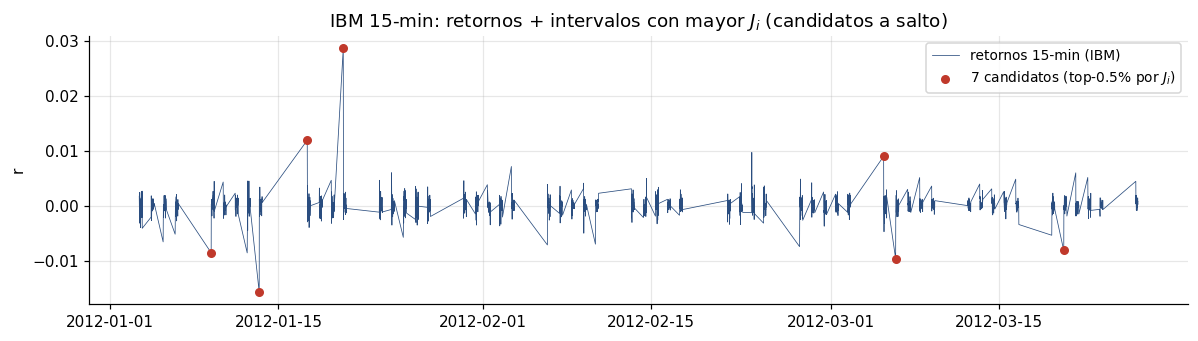

In [3]:
k = max(1, int(0.005 * N))
thr = np.sort(J)[::-1][k - 1]
flagged = J >= thr
print(f"umbral top-0.5%: J >= {thr:.3e}  ->  {int(flagged.sum())} intervalos candidatos")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(idx, rv, lw=0.5, color="#2a4d7f", label="retornos 15-min (IBM)")
ax.scatter(idx[flagged], rv[flagged], color="#c0392b", s=24, zorder=5,
           label=f"{int(flagged.sum())} candidatos (top-0.5% por $J_i$)")
ax.set_ylabel("r"); ax.legend(loc="upper right", fontsize=9)
ax.set_title("IBM 15-min: retornos + intervalos con mayor $J_i$ (candidatos a salto)")
fig.tight_layout(); plt.show()

## 4. La comparación clave: $r_i^2$ vs $J_i$

Arriba, $r_i^2$ se dispara tanto en los saltos **como** en las ventanas de alta
volatilidad continua y en las aperturas/cierres (forma-U). Abajo, $J_i$ es mucho más
dispersa: BPV cancela la varianza *continua* (donde los retornos adyacentes también son
grandes) y deja spikes sobre todo en saltos aislados. No es perfecta, pero es claramente
menos ruidosa que $r_i^2$ para aislar el componente de salto.

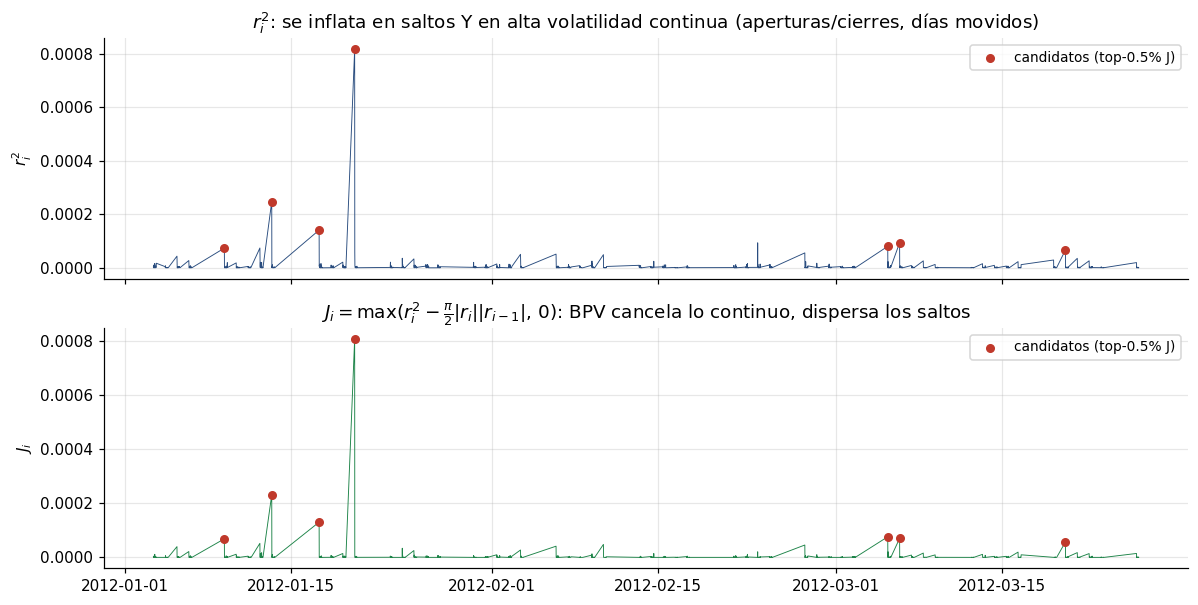

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
axes[0].plot(idx, r2, lw=0.6, color="#2a4d7f")
axes[0].scatter(idx[flagged], r2[flagged], color="#c0392b", s=24, zorder=5, label="candidatos (top-0.5% J)")
axes[0].set_ylabel(r"$r_i^2$")
axes[0].set_title(r"$r_i^2$: se inflata en saltos Y en alta volatilidad continua (aperturas/cierres, días movidos)")
axes[0].legend(loc="upper right", fontsize=9)

axes[1].plot(idx, J, lw=0.6, color="#1e8449")
axes[1].scatter(idx[flagged], J[flagged], color="#c0392b", s=24, zorder=5, label="candidatos (top-0.5% J)")
axes[1].set_ylabel(r"$J_i$")
axes[1].set_title(r"$J_i=\max(r_i^2-\frac{\pi}{2}|r_i||r_{i-1}|,\,0)$: BPV cancela lo continuo, dispersa los saltos")
axes[1].legend(loc="upper right", fontsize=9)
fig.tight_layout(); plt.show()

## 5. RV acumulada vs BPV acumulada — la separación limpia (sin verdad de campo)

$\sum r_i^2$ (RV) y $\sum \tfrac{\pi}{2}|r_i||r_{i-1}|$ (BPV) caminan juntas mientras no
hay saltos — ambas estiman la varianza continua integrada. En cada salto, **RV da un
escalón hacia arriba** pero **BPV no** (es robusta). La brecha entre las dos curvas es la
varianza aportada por los saltos: $RV - BPV$. En datos reales **ésta** es la señal limpia
que sustituye a la verdad de campo: si RV y BPV divergen puntualmente, ahí hay salto.

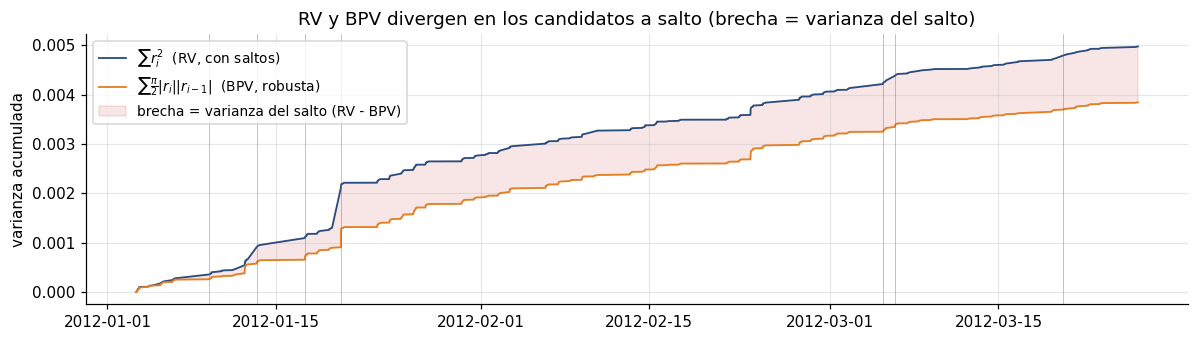

In [5]:
bpv_running = np.cumsum(bpv_term); rv_running = np.cumsum(r2)
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(idx, rv_running, color="#2a4d7f", lw=1.2, label=r"$\sum r_i^2$  (RV, con saltos)")
ax.plot(idx, bpv_running, color="#e67e22", lw=1.2, label=r"$\sum \frac{\pi}{2}|r_i||r_{i-1}|$  (BPV, robusta)")
ax.fill_between(idx, bpv_running, rv_running, where=rv_running >= bpv_running,
                color="#c0392b", alpha=0.12, label="brecha = varianza del salto (RV - BPV)")
for p in np.where(flagged)[0]:
    ax.axvline(idx[p], color="#c0392b", lw=0.6, alpha=0.4)
ax.set_ylabel("varianza acumulada"); ax.legend(loc="upper left", fontsize=9)
ax.set_title("RV y BPV divergen en los candidatos a salto (brecha = varianza del salto)")
fig.tight_layout(); plt.show()

## 6. El payoff real: limpiar RV antes de sumar

El pipeline no busca etiquetar saltos con alta precisión; **remueve los pocos intervalos
con mayor $J_i$** y *después* suma $r_i^2$ (re-escalando al largo total). Sin verdad de
campo, el criterio honesto es: ¿la limpieza **acerca $RV$ a $BPV$**? BPV es el estimador
robusto a saltos y proxy de la varianza del camino continuo; si limpiar reduce la brecha
$RV - BPV$, está haciendo lo correcto.

In [6]:
RV_raw = r2.sum()
BPV    = bpv_term.sum()

def clean_RV(k):
    keep = np.ones(N, bool); keep[np.argsort(J)[::-1][:k]] = False
    rv_clean = r2[keep].sum() * (N / keep.sum())          # re-escalado al largo total
    return rv_clean, int((~keep).sum()), int(keep.sum())

rows = [["RV cruda (∑r², sin limpiar)", RV_raw, abs(RV_raw-BPV)/BPV*100, "—"]]
for k in [max(1, int(0.005*N)), max(1, int(0.01*N))]:       # ~7 y ~15 intervalos
    rv_c, n_rm, _ = clean_RV(k)
    rows.append([f"RV limpia (remueve top-{k} por J)", rv_c, abs(rv_c-BPV)/BPV*100, str(n_rm)])
rows.append(["BPV (∑ π/2|r||r₋₁|) — robusta (referencia)", BPV, 0.0, "proxy ∫σ²"])

import pandas as _pd
tbl = _pd.DataFrame(rows, columns=["estimador", "valor", "dist. a BPV (%)", "intervalos removidos"])
tbl.style.format({"valor": "{:.3e}", "dist. a BPV (%)": "{:.1f}"})

,estimador,valor,dist. a BPV (%),intervalos removidos
0,"RV cruda (∑r², sin limpiar)",4.974e-03,29.4,—
1,RV limpia (remueve top-7 por J),3.470e-03,9.7,7
2,RV limpia (remueve top-15 por J),3.092e-03,19.5,15
3,BPV (∑ π/2|r||r₋₁|) — robusta (referencia),3.842e-03,0.0,proxy ∫σ²


## 7. Qué intervalos remueve la limpieza

El umbral (top $\sim$0.5 % de $J_i$) marca los intervalos más saltantes. Aún sin verdad
de campo, la pregunta operativa es si removerlos acerca $RV$ a $BPV$ — medido abajo.

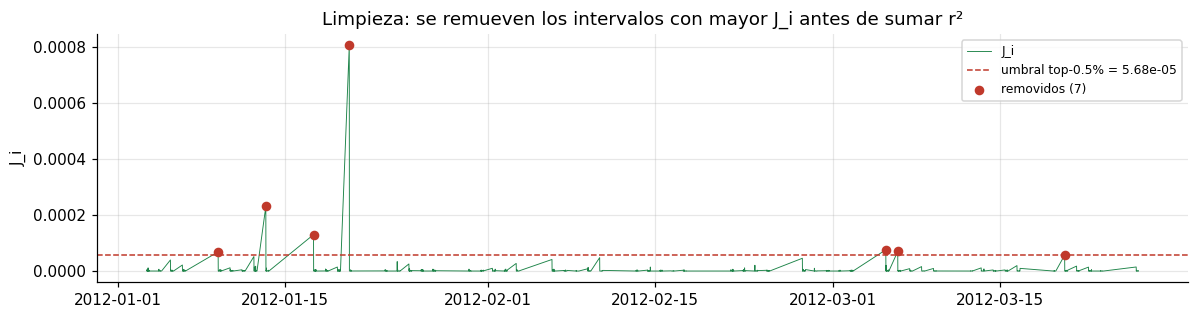

removidos=7 | RV cruda=4.974e-03 -> limpia=3.470e-03 (BPV=3.842e-03) | dist. a BPV: 29.4% -> 9.7%


In [7]:
k_clean = max(1, int(0.005*N))
thr = np.sort(J)[::-1][k_clean-1] if k_clean <= N else J.max()
flagged = J >= thr
fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(idx, J, lw=0.6, color="#1e8449", label="J_i")
ax.axhline(thr, color="#c0392b", ls="--", lw=1, label=f"umbral top-0.5% = {thr:.2e}")
ax.scatter(idx[flagged], J[flagged], color="#c0392b", s=28, zorder=5, label=f"removidos ({int(flagged.sum())})")
ax.set_ylabel("J_i"); ax.legend(loc="upper right", fontsize=8)
ax.set_title("Limpieza: se remueven los intervalos con mayor J_i antes de sumar r²")
fig.tight_layout(); plt.show()

rv_c, n_rm, _ = clean_RV(k_clean)
dist_raw = abs(RV_raw-BPV)/BPV*100
dist_clean = abs(rv_c-BPV)/BPV*100
msg = (f"removidos={n_rm} | RV cruda={RV_raw:.3e} -> limpia={rv_c:.3e} (BPV={BPV:.3e}) | "
       f"dist. a BPV: {dist_raw:.1f}% -> {dist_clean:.1f}%")
print(msg)


## 8. Conclusión

- $r_i^2$ es la **materia prima** de RV ($RV_t=\sum r_i^2$) pero **no** la separa de un
  salto: reacciona igual ante un salto que ante alta volatilidad continua (aperturas,
  días movidos).
- $J_i = r_i^2 - \tfrac{\pi}{2}|r_i||r_{i-1}|$ **resta la varianza continua** (BPV la
  estima sin saltos) y aísla el componente de salto.
- En **datos reales de IBM** (sin verdad de campo), la señal limpia es **agregada**: RV
  y BPV divergen en los candidatos a salto, y la brecha $RV - BPV$ = varianza del salto.
- El pipeline (Anzarut §4.2) usa $J_i$ para **limpiar**: remueve los pocos intervalos
  con mayor $J_i$ y luego suma $r_i^2$ → $RV_t$ estima la varianza del **camino continuo**.
  El criterio honesto de que funciona: la limpieza **acerca $RV$ a $BPV$** (el estimador
  robusto, proxy de $\int\sigma^2$), reduciendo la distorsión por saltos.

Fragmento en `data/ibm_fragment_15min.csv` (columna `r`, índice datetime). Loader:
`scripts/anzarut_replication.py::load_ibm_data`+`compute_15min_returns`.